# Main figure 1: pulse mechanism

This notebook builds the pulse-mechanism figure from the implemented echo-root-Lorentzian envelope. It shows the signed time-domain waveform, its waveform-only Fourier spectrum, and unitary two-level excited-state dynamics at resonance and at two finite detunings. Panel (c) contains no relaxation or dephasing.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'echospec').is_dir())
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.codex_tmp' / 'mpl'))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from qutip import basis, sesolve

from echospec.figures import FigureVariant, apply_figure_style, save_figure
from echospec.simulation.pulses import PulseArgs, PulseType, echo_lorentzian_envelope
from echospec.simulation.hamiltonian import Hamiltonian
from echospec.simulation.operators import N_dim, sz
from echospec.utils.parameters import Parameters
from echospec.utils.units import Units as u

VARIANT = FigureVariant.PAPER
apply_figure_style(VARIANT)
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy


## Parameters

The defaults below match the experimental pulse duration and cutoff used by the selected echo-Lorentzian dataset. Change them here to regenerate the complete figure consistently.

In [2]:
PULSE_LENGTH_US = 10.0
CUTOFF = 5e-3
ORDER = 0.5
RABI_MHZ = 15.0
DETUNINGS_MHZ = [0.0, 0.10, 2.00]
N_TIME = 1600
N_WAVEFORM = 2**14

pulse_length = PULSE_LENGTH_US * u.us
pulse_args = PulseArgs(pulse_length=pulse_length, cutoff=CUTOFF, order=ORDER)

In [3]:
# The pulse is sampled only on its finite hardware window, then zero padded for the FFT.
t = np.linspace(-pulse_length / 2, pulse_length / 2, N_WAVEFORM, endpoint=False)
omega = RABI_MHZ * echo_lorentzian_envelope(t, pulse_args)
dt = t[1] - t[0]
pad = 8 * N_WAVEFORM
omega_padded = np.pad(omega, (pad, pad))
freq_mhz = np.fft.fftshift(np.fft.fftfreq(omega_padded.size, dt)) / 1e6
spectrum = np.abs(np.fft.fftshift(np.fft.fft(omega_padded)))
spectrum /= spectrum.max()

trajectories = {}
for detuning_mhz in DETUNINGS_MHZ:
    params = Parameters(
        eco_pulse=True,
        pulse_type=PulseType.LORENTZIAN,
        pulse_length=pulse_length,
        cutoff=CUTOFF,
        order=ORDER,
        rabi_frequency=RABI_MHZ * 2 * np.pi * u.MHz,
        detuning=detuning_mhz * 2 * np.pi * u.MHz,
    )
    time = np.linspace(-pulse_length / 2, pulse_length / 2, N_TIME)
    result = sesolve(
        Hamiltonian(params=params).get_hamiltonian(),
        basis(N_dim, 0),
        time,
        e_ops=[sz],
    )
    trajectories[detuning_mhz] = (
        time / u.us,
        (1 - np.asarray(result.expect[0])) / 2,
    )

for detuning_mhz, (_, population) in trajectories.items():
    print(f'Detuning {detuning_mhz:+.2f} MHz: final P_e = {population[-1]:.3f}')

Detuning +0.00 MHz: final P_e = 0.000
Detuning +0.10 MHz: final P_e = 0.687
Detuning +2.00 MHz: final P_e = 0.964


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/01_pulse_mechanism.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/01_pulse_mechanism.svg')]

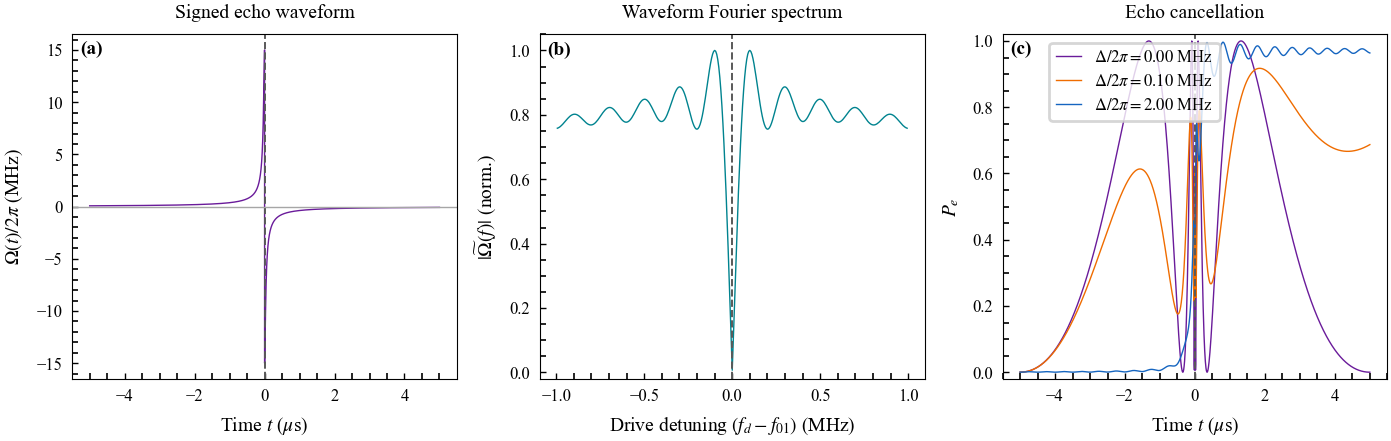

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.25), constrained_layout=True)
ax_time, ax_fft, ax_population = axes

ax_time.plot(t / u.us, omega, color='#6a1b9a')
ax_time.axvline(0, color='0.35', ls='--', lw=0.7)
ax_time.axhline(0, color='0.65', lw=0.5)
ax_time.set(xlabel=r'Time $t$ ($\mu$s)', ylabel=r'$\Omega(t)/2\pi$ (MHz)', title='Signed echo waveform')

fft_mask = np.abs(freq_mhz) <= 1.0
ax_fft.plot(freq_mhz[fft_mask], spectrum[fft_mask], color='#00838f')
ax_fft.axvline(0, color='0.35', ls='--', lw=0.7)
ax_fft.set(xlabel=r'Drive detuning $(f_d-f_{01})$ (MHz)', ylabel=r'$|\widetilde{\Omega}(f)|$ (norm.)', title='Waveform Fourier spectrum', ylim=(-0.02, 1.05))

colors = ['#6a1b9a', '#ef6c00', '#1565c0']
for color, (detuning_mhz, (time_us, population)) in zip(colors, trajectories.items()):
    ax_population.plot(time_us, population, color=color, label=rf'$\Delta/2\pi={detuning_mhz:.2f}$ MHz')
ax_population.axvline(0, color='0.35', ls='--', lw=0.7)
ax_population.set(xlabel=r'Time $t$ ($\mu$s)', ylabel=r'$P_e$', title='Echo cancellation', ylim=(-0.02, 1.02))
ax_population.legend(loc='upper left', bbox_to_anchor=(0.10, 1.0))

for label, ax in zip(['(a)', '(b)', '(c)'], axes):
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha='left', va='top', fontweight='bold')

saved = save_figure(fig, '01_pulse_mechanism', variant=VARIANT)
saved

### Interpretation

The FFT panel describes only the spectrum of the applied waveform. The population panel shows closed-system unitary dynamics with no $T_1$ relaxation or $T_2$ dephasing. At zero detuning the second pulse half exactly reverses the first-half evolution; finite detuning breaks that cancellation and leaves a larger final excitation.